In [1]:
import numpy as np
from matplotlib import pyplot as plt


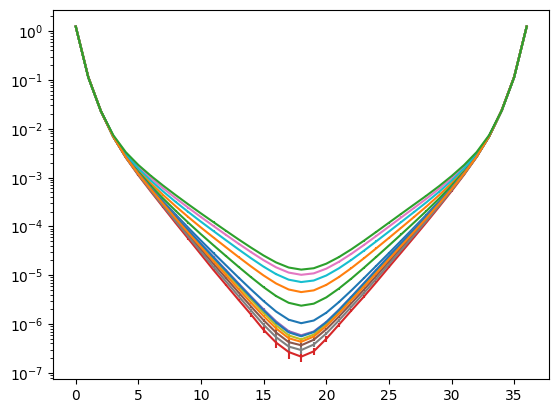

In [2]:
import os
datadir='correlator_zeroT_finiteB/'
lattice_data=[]
dir = os.path.realpath('./')
for file in os.listdir(datadir):
    if file.startswith('data_wilson'):
        lattice_correlator = np.loadtxt(os.path.join(dir,datadir,file))
        x = lattice_correlator[:,0]
        mean=lattice_correlator[:,1]
        error=lattice_correlator[:,2]
        Jackknife_samples = lattice_correlator[:,3:].T
        Nt=36
        zv=.829
        #add first point as last point to make it periodic
        x = np.append(x, len(x))
        mean = np.append(mean, mean[0])
        error = np.append(error, error[0])
        Jackknife_samples = np.append(Jackknife_samples, Jackknife_samples[:,0:1], axis=1)
        numpoints = len(x)
        lattice_data.append([x, mean, error, Jackknife_samples,file])

for x,mean,error,_,_ in lattice_data:
    plt.errorbar(x, mean, yerr=error)
plt.yscale('log')

In [3]:
from multiprocessing import Pool

epsilon=1e-10
omega = np.linspace(epsilon,20,500)
del_omega = omega[1]-omega[0]



lambda_s_warmup = 1.0e-5
lambda_l2_warmup = 1.0e-5
lambda_s = 3.55323189e-05#1.0e-5#1.0e-4
lambda_l2 = 6.66754659e-08#1.0e-8
epochs=2000
new_epochs = 100000


def func(lattice_data):

    import models
    import lossCalculator
    import correlator
    import tensorflow as tf


    x, mean, error, Jackknife_samples,file = lattice_data

    kl_ker_Pos=correlator.KL_kernel_Position_Vacuum(x,omega)
    klW_ker_Pos=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_FiniteT,x,omega,args=(1/Nt,))

    # Dxi = correlator.Di(kl_ker_Pos,bwfun,del_omega)

    # # noisy_Dxi,custom_std=correlator.generateNoisyCorrelator(Dxi,x,base_ep_noise,seed=correlatorseed)
    # # if num_samples == 1:
    # #     noisy_dxi_tensor.append(noisy_Dxi)
    # # else:
    # #     for ii in range(num_samples):
    # #         noisy_Dxi_sample,custom_std=correlator.generateNoisyCorrelator(noisy_Dxi,x,ep_noise)
    # #         noisy_dxi_tensor.append(noisy_Dxi_sample)

    # Dxi = correlator.Di(kl_ker_Pos,bwfun,del_omega)
    # noisy_dxi_tensor, base_noisy_Dxi, custom_std = correlator.generateNoisyCorrelatorEnsemble(Dxi,x,ep_noise,num_samples,mean_noise=base_ep_noise, seed=1)
    noisy_dxi_tensor = Jackknife_samples

    # num_samples = 30
    gauss_width = np.ones(len(x)) #for mean square error
    gauss_width=error
    constant_input = tf.constant([[1.0]], dtype=tf.float32) #NN
    kern=klW_ker_Pos


    model = models.SpectralNN(num_output_nodes=500, width=32, depth=3)
    target_output=noisy_dxi_tensor
    lossCalc=lossCalculator.LossCalculator(model=model,
                                        y_true=target_output,
                                        kernel=kern,
                                        delomega=del_omega,
                                        x=constant_input,
                                        std=gauss_width,
                                        lambda_s_func_warmup=lambda x:lambda_s_warmup,
                                        lambda_s_func=lambda x:lambda_s,
                                        lambda_l2_func_warmup=lambda x:lambda_l2_warmup,
                                        lambda_l2_func=lambda x:lambda_l2
                                            )
    # Compile the model - one can also play with learning rate initially it is kept large to scan through a broader manifold of minima and later decreased
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
    trainer=models.networkTrainer(model,optimizer,lossCalc)
    total_loss_history_warmup,loss_history_warmup=trainer.train(epochs,warmup=True,verbose=True)

    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4) #notice the lower learning rate
    trainer.optimizer=optimizer
    total_loss_history,loss_history=trainer.train(new_epochs,warmup=False,verbose=True)

    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5) #notice the lower learning rate
    trainer.optimizer=optimizer
    total_loss_history_2,loss_history_2=trainer.train(3000,warmup=False,verbose=True)

    total_loss_history.extend(total_loss_history_2)
    loss_history.extend(loss_history_2)

    rhoOverOmega=model(constant_input)
    # rho_list.append(rho)
    # total_loss_history_list.append(total_loss_history)
    # loss_history_list.append(loss_history)
    return rhoOverOmega,total_loss_history,loss_history,x,mean,error,file




pool=Pool(13)
rhoOverOmega_list,total_loss_history_list,loss_history_list,x,noisy_Dxi,error,file=zip(*pool.map(func,lattice_data))

# results.wait()

pool.close()
rhoOverOmega_list=np.array(rhoOverOmega_list)
total_loss_history_list=np.array(total_loss_history_list)
loss_history_list=np.array(loss_history_list)
x=np.array(x)
noisy_Dxi=np.array(noisy_Dxi)
error=np.array(error)
file=np.array(file)


2025-01-22 14:47:45.558548: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-22 14:47:45.558549: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-22 14:47:45.558550: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-22 14:47:45.558551: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly 

Training for 2000 epochs
Training for 2000 epochs
Training for 2000 epochs
Training for 2000 epochs
Training for 2000 epochs
Training for 2000 epochs


2025-01-22 14:47:46.777208: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-01-22 14:47:46.781725: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-01-22 14:47:46.833743: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-01-22 14:47:46.869721: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-01-22 14:47:46.894585: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-01-22 14:47:46.911335: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:1

Epoch 0, Loss: 22107.53515625
Training for 2000 epochs
Epoch 0, Loss: 125456.796875
Epoch 0, Loss: 1915.2017822265625
Epoch 0, Loss: 48099.125
Epoch 0, Loss: 2791.98486328125
Training for 2000 epochs
Epoch 0, Loss: 17177.65625


2025-01-22 14:47:47.003305: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-01-22 14:47:47.096983: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


...

Epoch 200, Loss: 25.8378963470459
Epoch 200, Loss: 65.54840087890625
Epoch 200, Loss: 2.7068307399749756
Epoch 200, Loss: 0.9636676907539368
Epoch 200, Loss: 8.378040313720703
Epoch 200, Loss: 129.82275390625
Epoch 200, Loss: 21.328876495361328
Epoch 200, Loss: 88.23482513427734
Epoch 200, Loss: 1.4959205389022827
Epoch 400, Loss: 6.237062931060791
Epoch 200, Loss: 1.2890100479125977
Epoch 400, Loss: 0.6334896087646484
Epoch 400, Loss: 16.183544158935547
Epoch 400, Loss: 1.9444446563720703
Epoch 400, Loss: 32.31388854980469
Epoch 400, Loss: 5.259111404418945
Epoch 200, Loss: 21.777812957763672
Epoch 400, Loss: 22.75067901611328
Epoch 200, Loss: 31.722455978393555
Epoch 200, Loss: 159.91241455078125
Epoch 400, Loss: 0.22499793767929077
Epoch 600, Loss: 2.744241952896118
Epoch 600, Loss: 14.377768516540527
Epoch 600, Loss: 0.8441986441612244
Epoch 600, Loss: 2.325225591659546
Epoch 600, Loss: 10.169092178344727
Epoch 600, Loss: 7.174542427062988
Epoch 400, Loss: 41.55913543701172
Epoch 4

2025-01-22 15:10:22.679435: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-22 15:10:22.680669: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-22 15:10:22.684899: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-22 15:10:22.699976: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1737555022.717663   35120 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1737555022.72

Epoch 300, Loss: 6.0799511629738845e-06


2025-01-22 15:10:24.862688: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 900, Loss: 1.2554336535686161e-05
Epoch 600, Loss: 6.078450496715959e-06
Epoch 1200, Loss: 1.255261759069981e-05
Epoch 900, Loss: 6.076837962609716e-06
Epoch 1500, Loss: 1.2550849532999564e-05
Epoch 1200, Loss: 6.075238616176648e-06
Epoch 1800, Loss: 1.2549188795674127e-05
Epoch 1500, Loss: 6.074355042073876e-06
Epoch 2100, Loss: 1.2547337064461317e-05
Epoch 1800, Loss: 6.071717052691383e-06
Epoch 2400, Loss: 1.254546077689156e-05
Epoch 2100, Loss: 6.069983101042453e-06
Epoch 2700, Loss: 1.2543735465442296e-05
Epoch 2400, Loss: 6.068225047783926e-06
Epoch 90000, Loss: 7.068746981531149e-06
Epoch 2700, Loss: 6.066479727451224e-06
Training took 42.931167125701904 seconds
Epoch 80000, Loss: 9.12471477931831e-06
Training took 41.45362329483032 seconds
Epoch 90000, Loss: 8.646535206935368e-06
Epoch 70000, Loss: 6.164411843201378e-06
Epoch 90000, Loss: 1.2128413800382987e-05
Epoch 70000, Loss: 7.244490461744135e-06
Epoch 80000, Loss: 7.026389539532829e-06
Training took 1446.95627331733

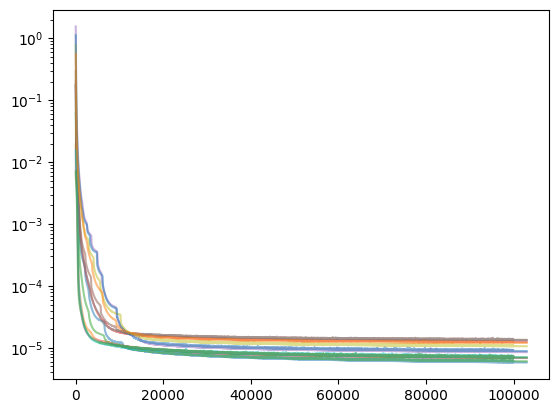

In [6]:
for loss in total_loss_history_list:
    plt.plot(loss,alpha=0.5)
plt.yscale('log')

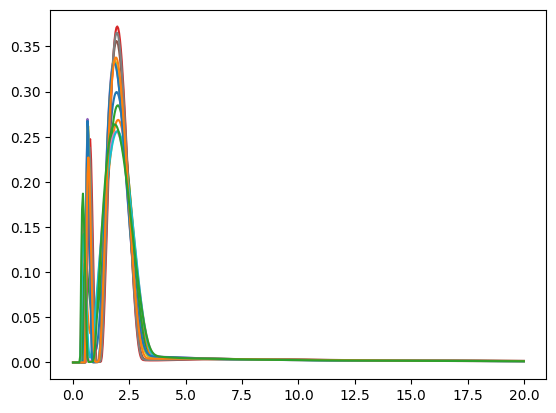

In [4]:
for f,rhoOverOmega in zip(file,rhoOverOmega_list):
    dat=np.column_stack((omega,rhoOverOmega[0]))
    np.savetxt(datadir+"RhoOverOmega_errorWeighting_"+f,dat)
    plt.plot(omega,rhoOverOmega[0])

Text(0.5, 1.0, '$48^3\\times 16, \\beta=6.872$')

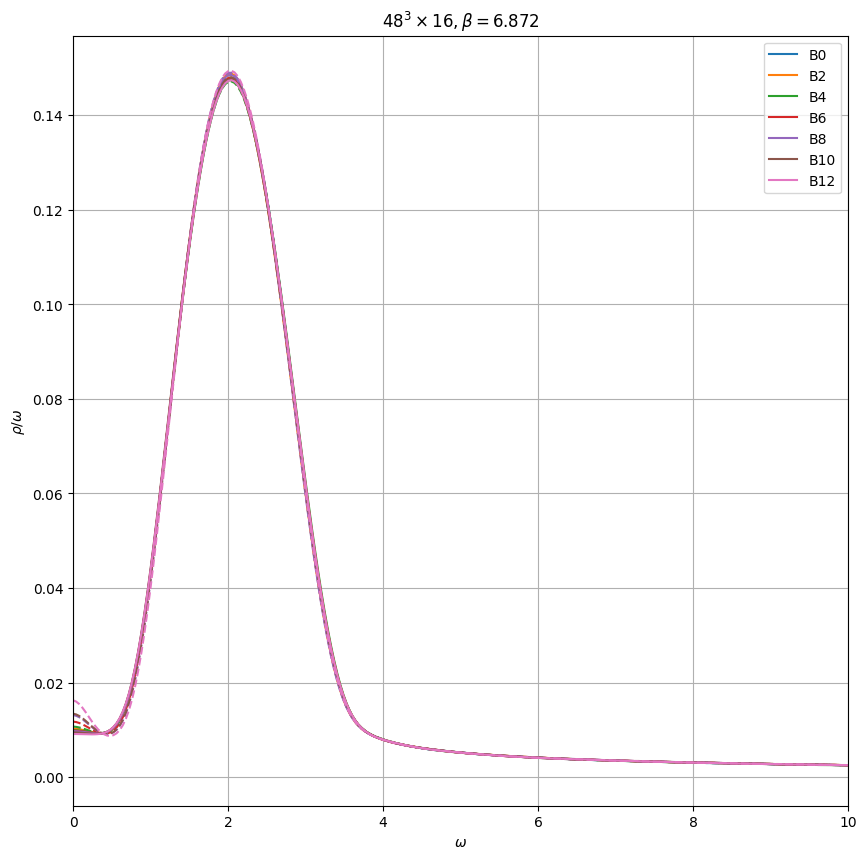

In [35]:
import matplotlib.pyplot as plt
import numpy as np
Nt=16
files=[
["correlator_zeroT_finiteB/RhoOverOmega_data_wilson_emconduc_24_36_b5.845_B0_x.txt",
"correlator_zeroT_finiteB/RhoOverOmega_data_wilson_emconduc_24_36_b5.845_B0_x.txt","B0"],
["correlator_zeroT_finiteB/RhoOverOmega_data_wilson_emconduc_24_36_b5.845_B2_x.txt",
"correlator_zeroT_finiteB/RhoOverOmega_data_wilson_emconduc_24_36_b5.845_B2_z.txt","B2"],
["correlator_zeroT_finiteB/RhoOverOmega_data_wilson_emconduc_24_36_b5.845_B4_x.txt",
"correlator_zeroT_finiteB/RhoOverOmega_data_wilson_emconduc_24_36_b5.845_B4_z.txt","B4"],
["correlator_zeroT_finiteB/RhoOverOmega_data_wilson_emconduc_24_36_b5.845_B6_x.txt",
"correlator_zeroT_finiteB/RhoOverOmega_data_wilson_emconduc_24_36_b5.845_B6_z.txt","B6"],
["correlator_zeroT_finiteB/RhoOverOmega_data_wilson_emconduc_24_36_b5.845_B8_x.txt",
"correlator_zeroT_finiteB/RhoOverOmega_data_wilson_emconduc_24_36_b5.845_B8_z.txt","B8"],
["correlator_zeroT_finiteB/RhoOverOmega_data_wilson_emconduc_24_36_b5.845_B10_x.txt",
"correlator_zeroT_finiteB/RhoOverOmega_data_wilson_emconduc_24_36_b5.845_B10_z.txt","B10"],
["correlator_zeroT_finiteB/RhoOverOmega_data_wilson_emconduc_24_36_b5.845_B12_x.txt",
"correlator_zeroT_finiteB/RhoOverOmega_data_wilson_emconduc_24_36_b5.845_B12_z.txt","B12"],
]

f=plt.figure()
f.set_size_inches(10,10)
zv=.829
colors=['C0','C1','C2','C3','C4','C5','C6']
for (file1,file2,label),c in zip(files,colors):
    dat1 = np.loadtxt(file1)
    dat2 = np.loadtxt(file2)
    plt.plot(dat1[:,0],dat1[:,1], label=label,color=c)
    plt.plot(dat2[:,0],dat2[:,1],ls='--',color=c)
plt.xlim(0,10.0)
# plt.ylim(0.005,0.02)
plt.grid()
plt.legend()
plt.ylabel(r'$\rho/\omega$')
plt.xlabel(r'$\omega$')
plt.title(r'$24^3\times 36, \beta=5.845$')

Text(0.5, 1.0, '$24^3\\times 36, \\beta=5.845$')

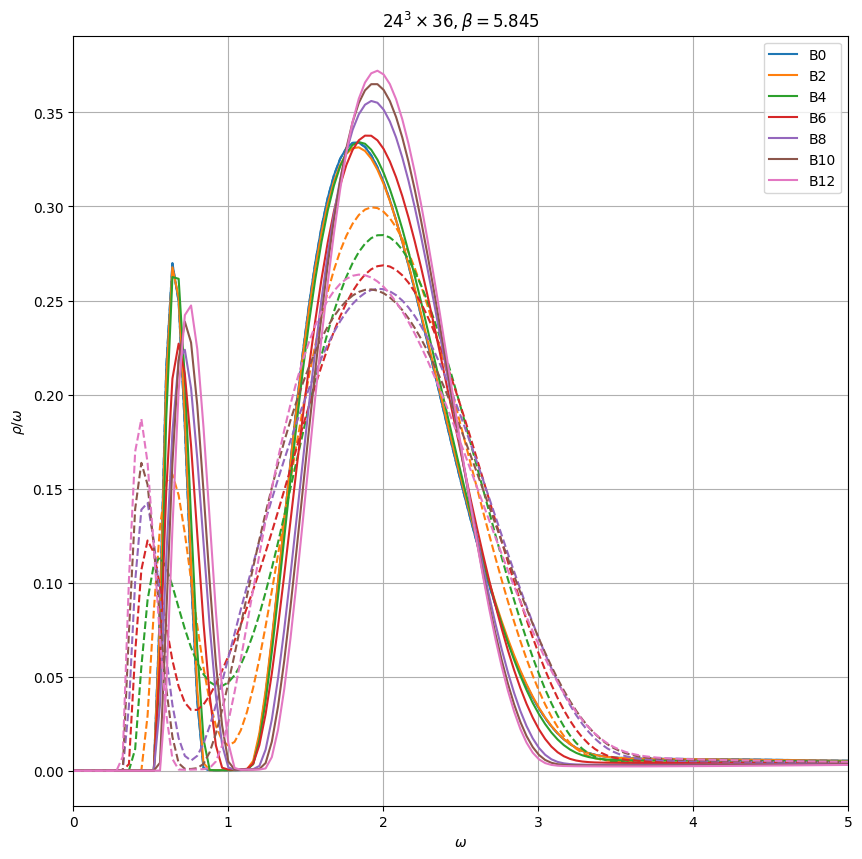

In [8]:
import matplotlib.pyplot as plt
import numpy as np
Nt=16
files=[
["correlator_zeroT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_24_36_b5.845_B0_x.txt",
 "correlator_zeroT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_24_36_b5.845_B0_x.txt","B0"],
["correlator_zeroT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_24_36_b5.845_B2_x.txt",
 "correlator_zeroT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_24_36_b5.845_B2_z.txt","B2"],
["correlator_zeroT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_24_36_b5.845_B4_x.txt",
 "correlator_zeroT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_24_36_b5.845_B4_z.txt","B4"],
["correlator_zeroT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_24_36_b5.845_B6_x.txt",
 "correlator_zeroT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_24_36_b5.845_B6_z.txt","B6"],
["correlator_zeroT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_24_36_b5.845_B8_x.txt",
 "correlator_zeroT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_24_36_b5.845_B8_z.txt","B8"],
["correlator_zeroT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_24_36_b5.845_B10_x.txt",
 "correlator_zeroT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_24_36_b5.845_B10_z.txt","B10"],
["correlator_zeroT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_24_36_b5.845_B12_x.txt",
 "correlator_zeroT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_24_36_b5.845_B12_z.txt","B12"],
]

f=plt.figure()
f.set_size_inches(10,10)
zv=.829
colors=['C0','C1','C2','C3','C4','C5','C6']
for (file1,file2,label),c in zip(files,colors):
    dat1 = np.loadtxt(file1)
    dat2 = np.loadtxt(file2)
    plt.plot(dat1[:,0],dat1[:,1], label=label,color=c)
    plt.plot(dat2[:,0],dat2[:,1],ls='--',color=c)
plt.xlim(0,5.0)
# plt.ylim(0.005,0.02)
# plt.xlim(0,1.0)
# # plt.ylim(0.001,0.03)
plt.grid()
plt.legend()
plt.ylabel(r'$\rho/\omega$')
plt.xlabel(r'$\omega$')
plt.title(r'$24^3\times 36, \beta=5.845$')

Text(0.5, 1.0, '$48^3\\times 16, \\beta=6.872$')

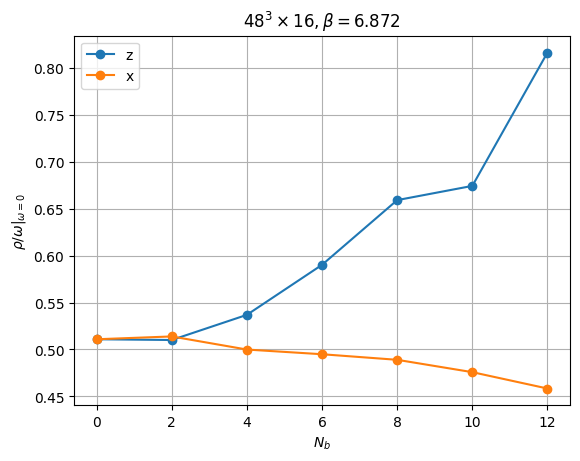

In [36]:
f=plt.figure()
# f.set_size_inches(10,10)
# zv=.829
Nt=16
colors=['C0','C1','C2','C3','C4','C5','C6']
zdat=[]
xdat=[]
for (file1,file2,label),c in zip(files,colors):
    dat1 = np.loadtxt(file1)
    dat2 = np.loadtxt(file2)
    xdat.append(dat1[:,1][0])
    zdat.append(dat2[:,1][0])

zdat=np.array(zdat)
xdat=np.array(xdat)

brange=[0,2,4,6,8,10,12]
plt.plot(brange,zdat*Nt*np.pi,'o-',label=r'z')
plt.plot(brange,xdat*Nt*np.pi,'o-',label=r'x')


plt.grid()
plt.legend()
plt.ylabel(r'$\rho/\omega|_{\omega=0}$')
plt.xlabel(r'$N_b$')
plt.title(r'$24^3\times 36, \beta=5.845$')

In [10]:
dean_results=[
    np.loadtxt('correlator_zeroT_finiteB/dean_gauss_results/elec_cond_x_beta5.845.dat'),
    np.loadtxt('correlator_zeroT_finiteB/dean_gauss_results/elec_cond_z_beta5.845.dat'),
    np.loadtxt('correlator_zeroT_finiteB/dean_gauss_results/elec_cond_x_beta6.872.dat'),
    np.loadtxt('correlator_zeroT_finiteB/dean_gauss_results/elec_cond_z_beta6.872.dat'),
]


Text(0.5, 1.0, '$24^3\\times 36, \\beta=5.845$')

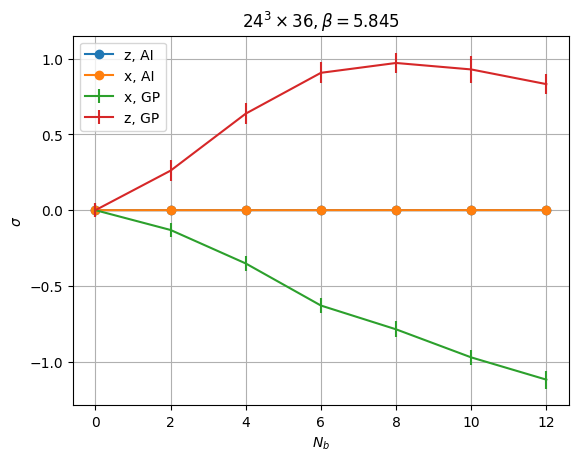

In [11]:
f=plt.figure()
# f.set_size_inches(10,10)
# zv=.829
Nt=16
colors=['C0','C1','C2','C3','C4','C5','C6']
zdat=[]
xdat=[]
for (file1,file2,label),c in zip(files,colors):
    dat1 = np.loadtxt(file1)
    dat2 = np.loadtxt(file2)
    xdat.append(dat1[:,1][0])
    zdat.append(dat2[:,1][0])

zdat=np.array(zdat)
xdat=np.array(xdat)

brange=[0,2,4,6,8,10,12]
plt.plot(brange,zdat*Nt*np.pi-zdat[0]*Nt*np.pi,'o-',label=r'z, AI')
plt.plot(brange,xdat*Nt*np.pi-zdat[0]*Nt*np.pi,'o-',label=r'x, AI')
plt.errorbar(brange,dean_results[0][:,1]-dean_results[0][:,1][0],yerr=dean_results[2][:,2],label=r'x, GP')
plt.errorbar(brange,dean_results[1][:,1]-dean_results[1][:,1][0],yerr=dean_results[3][:,2],label=r'z, GP')


plt.grid()
plt.legend()
plt.ylabel(r'$\sigma$')
plt.xlabel(r'$N_b$')
plt.title(r'$24^3\times 36, \beta=5.845$')

Text(0.5, 1.0, '$48^3\\times 16, \\beta=6.872$')

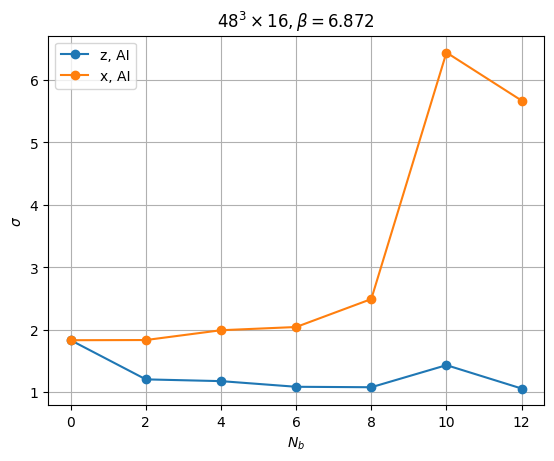

In [26]:
f=plt.figure()
# f.set_size_inches(10,10)
# zv=.829
Nt=16
colors=['C0','C1','C2','C3','C4','C5','C6']
zdat=[]
xdat=[]
for (file1,file2,label),c in zip(files,colors):
    dat1 = np.loadtxt(file1)
    dat2 = np.loadtxt(file2)
    xdat.append(dat1[:,1][0])
    zdat.append(dat2[:,1][0])

zdat=np.array(zdat)
xdat=np.array(xdat)

brange=[0,2,4,6,8,10,12]
plt.plot(brange,zdat*Nt*np.pi/dean_results[3][:,1],'o-',label=r'z, AI')
plt.plot(brange,xdat*Nt*np.pi/dean_results[2][:,1],'o-',label=r'x, AI')



plt.grid()
plt.legend()
plt.ylabel(r'$\sigma$')
plt.xlabel(r'$N_b$')
plt.title(r'$24^3\times 36, \beta=5.845$')

In [36]:

for x,mean,error,jack,file in lattice_data:
    print(file)

data_wilson_emconduc_48_16_b6.872_B8_z.txt
data_wilson_emconduc_48_16_b6.872_B4_z.txt
data_wilson_emconduc_48_16_b6.872_B4_x.txt
data_wilson_emconduc_48_16_b6.872_B12_x.txt
data_wilson_emconduc_48_16_b6.872_B6_z.txt
data_wilson_emconduc_48_16_b6.872_B2_z.txt
data_wilson_emconduc_48_16_b6.872_B10_x.txt
data_wilson_emconduc_48_16_b6.872_B0_x.txt
data_wilson_emconduc_48_16_b6.872_B10_z.txt
data_wilson_emconduc_48_16_b6.872_B12_z.txt
data_wilson_emconduc_48_16_b6.872_B8_x.txt
data_wilson_emconduc_48_16_b6.872_B6_x.txt
data_wilson_emconduc_48_16_b6.872_B2_x.txt


In [12]:
import correlator
import numpy as np
import matplotlib.pyplot as plt

epsilon=1e-10
omega = np.linspace(epsilon,20,500)
del_omega = omega[1]-omega[0]
klW_ker_Pos=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_FiniteT,x,omega,args=(1/Nt,))
allFiles=[
["correlator_zeroT_finiteB/RhoOverOmega_data_wilson_emconduc_24_36_b5.845_B0_x.txt", "correlator_zeroT_finiteB/data_wilson_emconduc_24_36_b5.845_B0_x.txt", "B0, x"],
["correlator_zeroT_finiteB/RhoOverOmega_data_wilson_emconduc_24_36_b5.845_B0_x.txt", "correlator_zeroT_finiteB/data_wilson_emconduc_24_36_b5.845_B0_x.txt", "B0, z"],
["correlator_zeroT_finiteB/RhoOverOmega_data_wilson_emconduc_24_36_b5.845_B2_x.txt", "correlator_zeroT_finiteB/data_wilson_emconduc_24_36_b5.845_B2_x.txt", "B2, x"],
["correlator_zeroT_finiteB/RhoOverOmega_data_wilson_emconduc_24_36_b5.845_B2_z.txt", "correlator_zeroT_finiteB/data_wilson_emconduc_24_36_b5.845_B2_z.txt", "B2, z"],
["correlator_zeroT_finiteB/RhoOverOmega_data_wilson_emconduc_24_36_b5.845_B4_x.txt", "correlator_zeroT_finiteB/data_wilson_emconduc_24_36_b5.845_B4_x.txt", "B4, x"],
["correlator_zeroT_finiteB/RhoOverOmega_data_wilson_emconduc_24_36_b5.845_B4_z.txt", "correlator_zeroT_finiteB/data_wilson_emconduc_24_36_b5.845_B4_z.txt", "B4, z"],
["correlator_zeroT_finiteB/RhoOverOmega_data_wilson_emconduc_24_36_b5.845_B6_x.txt", "correlator_zeroT_finiteB/data_wilson_emconduc_24_36_b5.845_B6_x.txt", "B6, x"],
["correlator_zeroT_finiteB/RhoOverOmega_data_wilson_emconduc_24_36_b5.845_B6_z.txt", "correlator_zeroT_finiteB/data_wilson_emconduc_24_36_b5.845_B6_z.txt", "B6, z"],
["correlator_zeroT_finiteB/RhoOverOmega_data_wilson_emconduc_24_36_b5.845_B8_x.txt", "correlator_zeroT_finiteB/data_wilson_emconduc_24_36_b5.845_B8_x.txt", "B8, x"],
["correlator_zeroT_finiteB/RhoOverOmega_data_wilson_emconduc_24_36_b5.845_B8_z.txt", "correlator_zeroT_finiteB/data_wilson_emconduc_24_36_b5.845_B8_z.txt", "B8, z"],
["correlator_zeroT_finiteB/RhoOverOmega_data_wilson_emconduc_24_36_b5.845_B10_x.txt","correlator_zeroT_finiteB/data_wilson_emconduc_24_36_b5.845_B10_x.txt","B10, x"],
["correlator_zeroT_finiteB/RhoOverOmega_data_wilson_emconduc_24_36_b5.845_B10_z.txt","correlator_zeroT_finiteB/data_wilson_emconduc_24_36_b5.845_B10_z.txt","B10, z"],
["correlator_zeroT_finiteB/RhoOverOmega_data_wilson_emconduc_24_36_b5.845_B12_x.txt","correlator_zeroT_finiteB/data_wilson_emconduc_24_36_b5.845_B12_x.txt","B12, x"],
["correlator_zeroT_finiteB/RhoOverOmega_data_wilson_emconduc_24_36_b5.845_B12_z.txt","correlator_zeroT_finiteB/data_wilson_emconduc_24_36_b5.845_B12_z.txt","B12, z"],
]

lattice_data=[]
reconstructed_data=[]
for rhoFile,correlatorFile,Label in allFiles:        
    lattice_correlator = np.loadtxt(correlatorFile)
    x = lattice_correlator[:,0]
    mean=lattice_correlator[:,1]
    error=lattice_correlator[:,2]
    Jackknife_samples = lattice_correlator[:,3:].T
    Nt=16
    zv=.829
    #add first point as last point to make it periodic
    x = np.append(x, len(x))
    mean = np.append(mean, mean[0])
    error = np.append(error, error[0])
    Jackknife_samples = np.append(Jackknife_samples, Jackknife_samples[:,0:1], axis=1)
    numpoints = len(x)
    lattice_data.append([x, mean, error, Jackknife_samples,Label])
    rhoOverOmega = np.loadtxt(rhoFile)
    rhoOverOmega = rhoOverOmega[:,1]
    Dxi_reconstructed = correlator.Di(klW_ker_Pos,rhoOverOmega,del_omega)
    reconstructed_data.append([x,Dxi_reconstructed,Label])


/tmp/ipykernel_30367/796913344.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


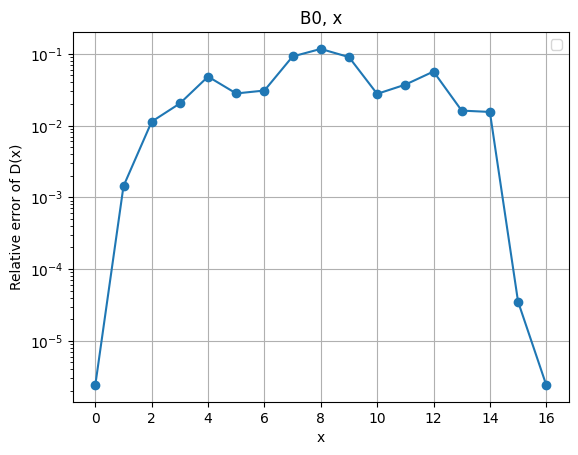

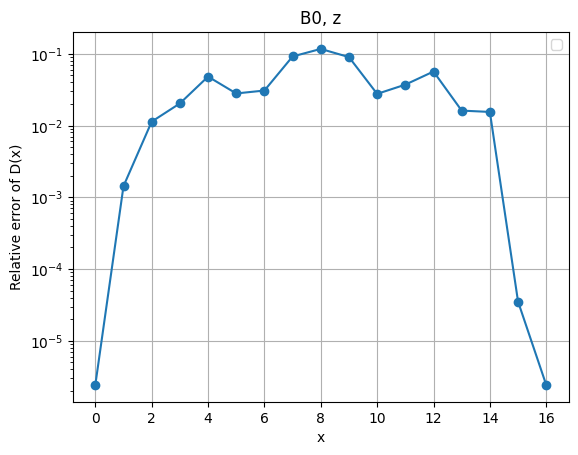

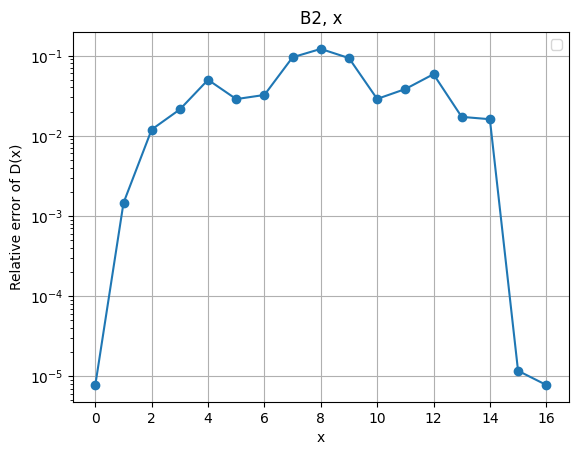

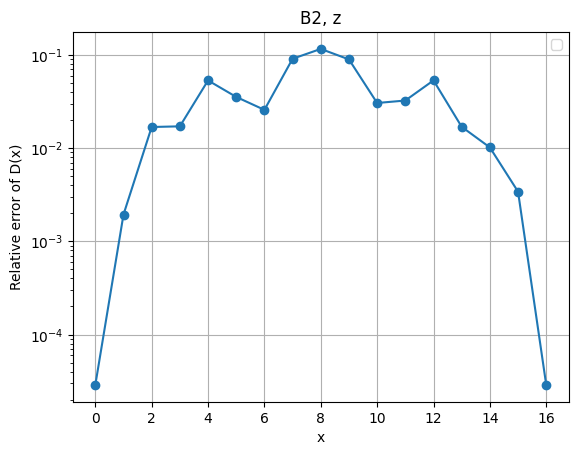

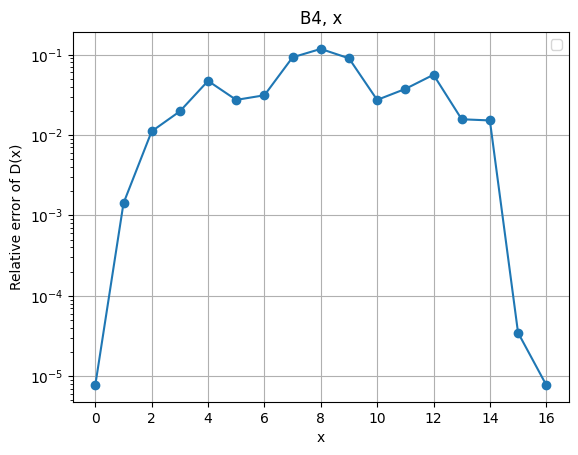

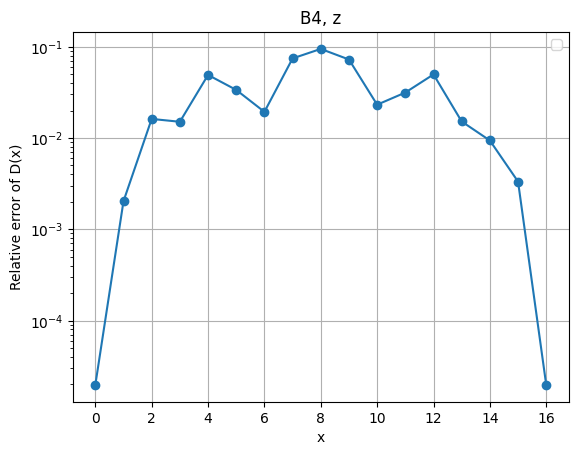

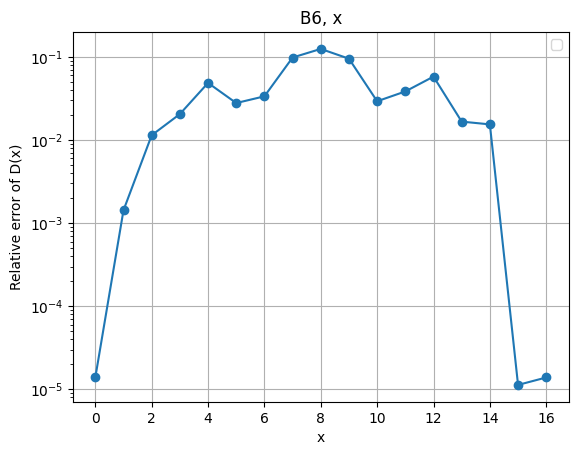

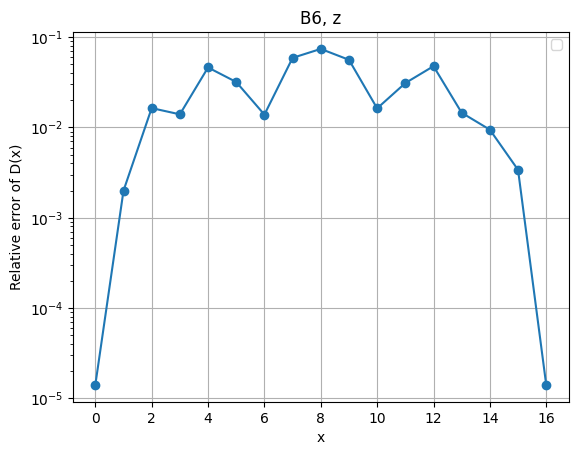

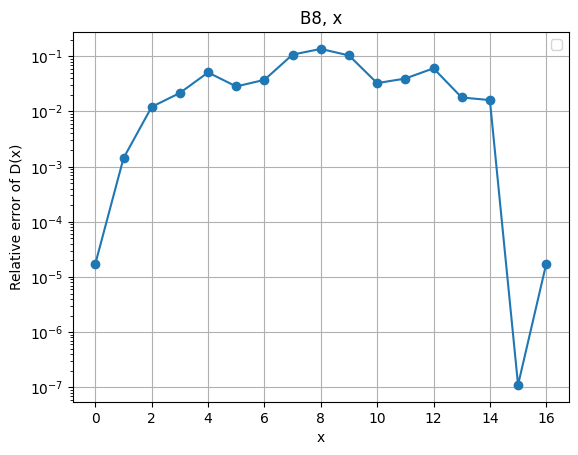

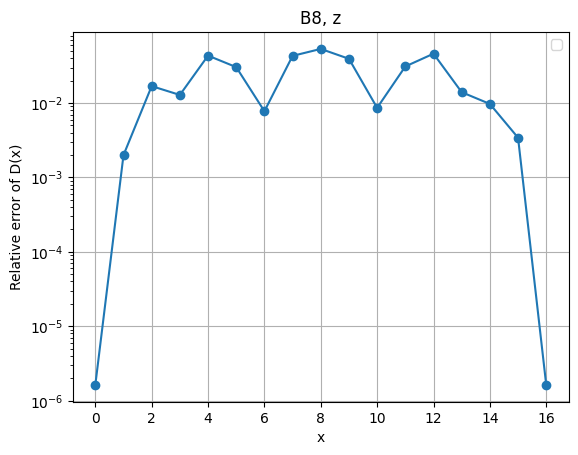

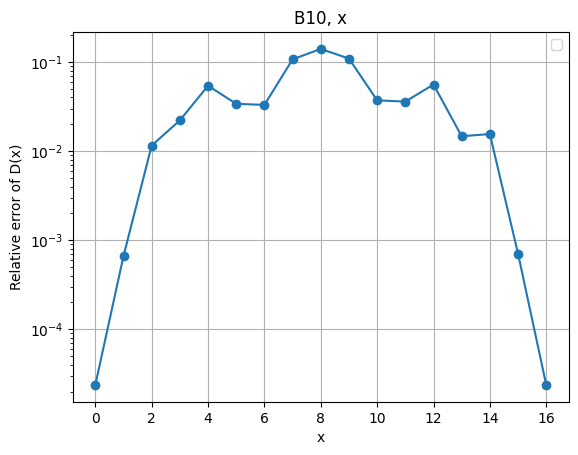

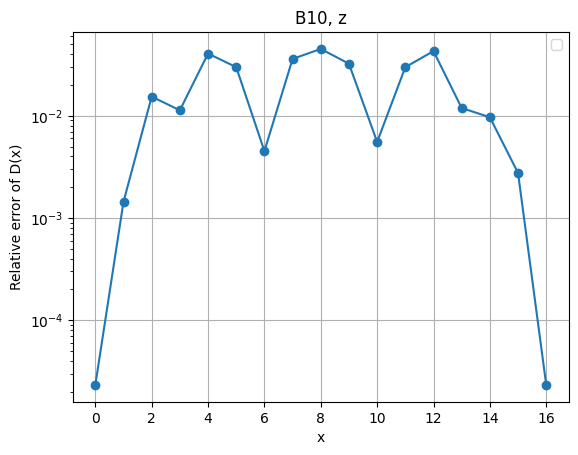

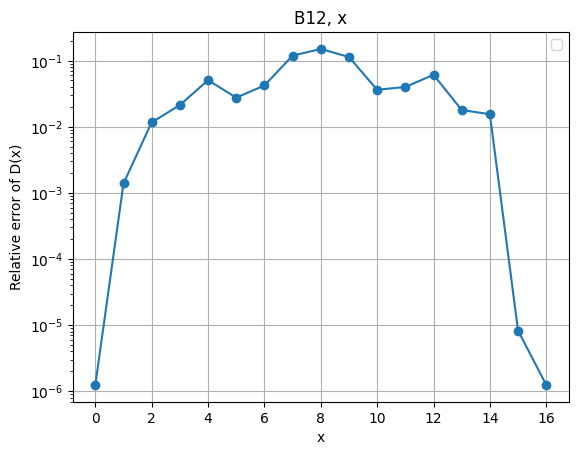

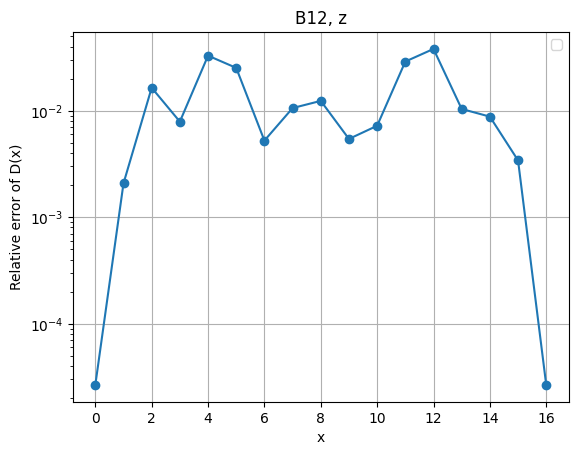

In [13]:
for (x,mean,error,jack,Label),(x_reconstructed,Dxi_reconstructed,Label) in zip(lattice_data,reconstructed_data):
    f=plt.figure()
    # plt.errorbar(x, mean, yerr=error,label='Data',fmt='',ls='',capsize=5)
    # plt.plot(x_reconstructed,Dxi_reconstructed,label='Reconstructed')
    plt.plot(x,np.abs(mean-Dxi_reconstructed)/mean,'o-')
    plt.title(Label)
    plt.yscale('log')
    plt.xlabel('x')
    plt.ylabel('Relative error of D(x)')
    plt.grid()
    plt.legend()
    # plt.ylim(1e-4,1e0)

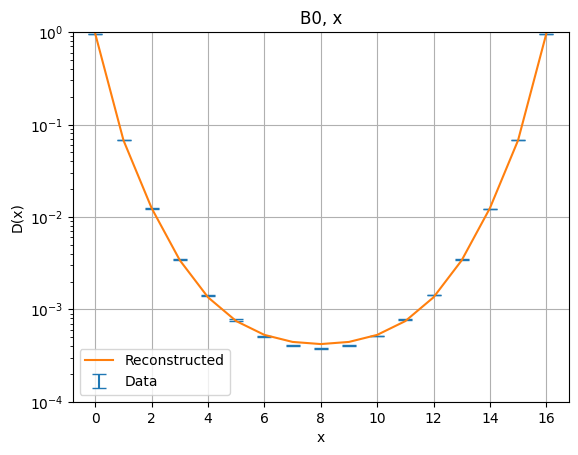

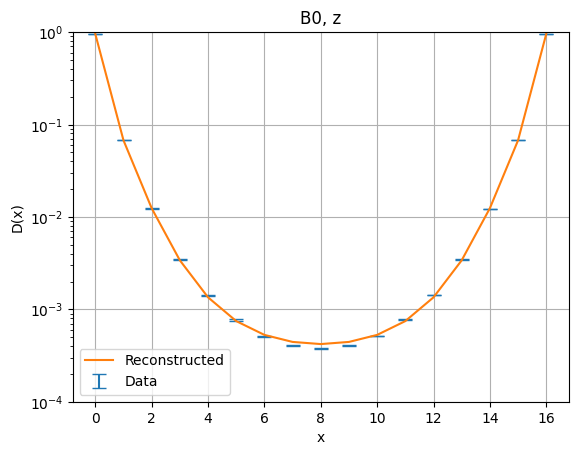

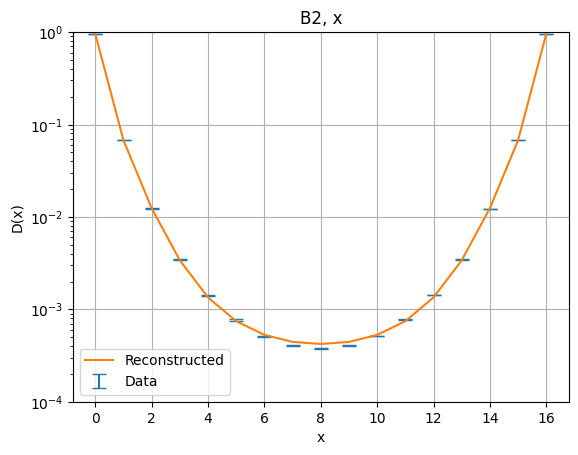

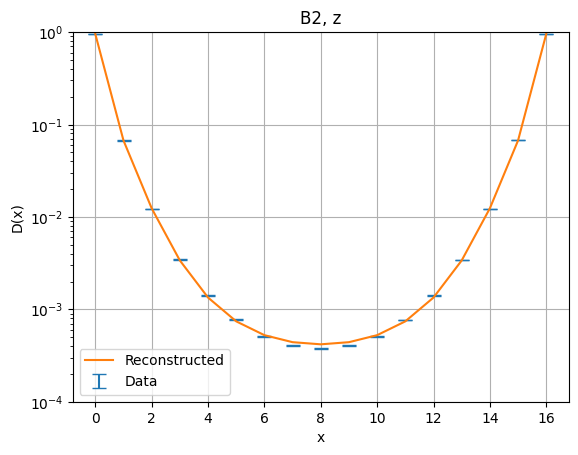

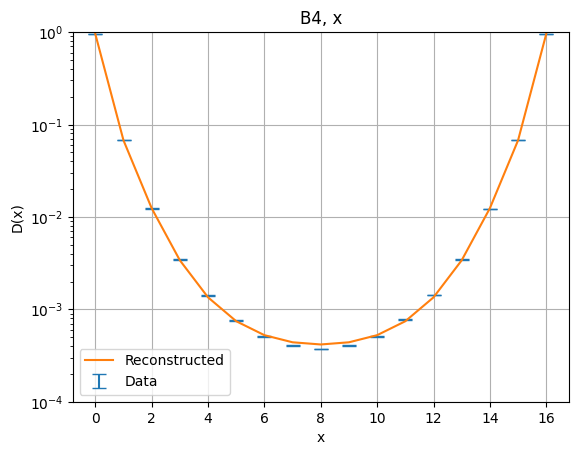

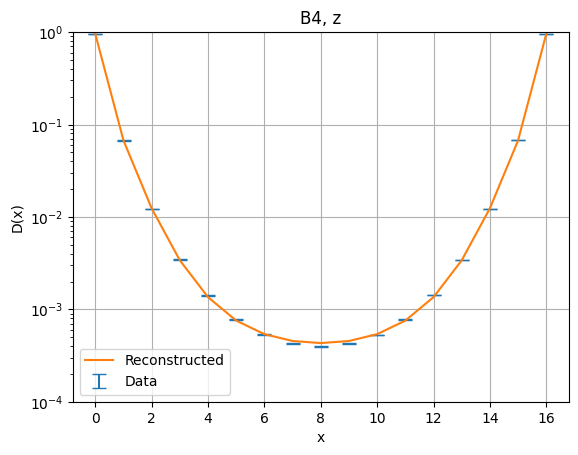

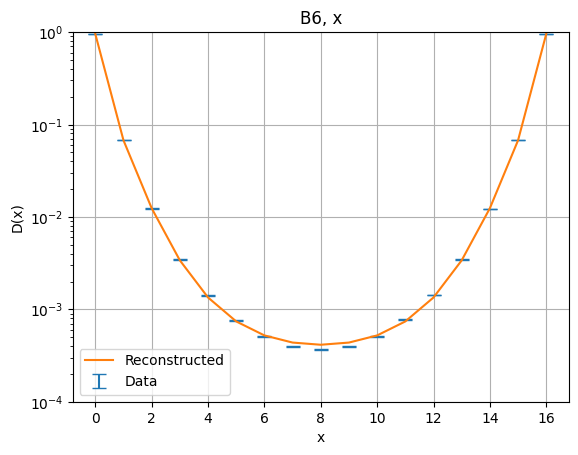

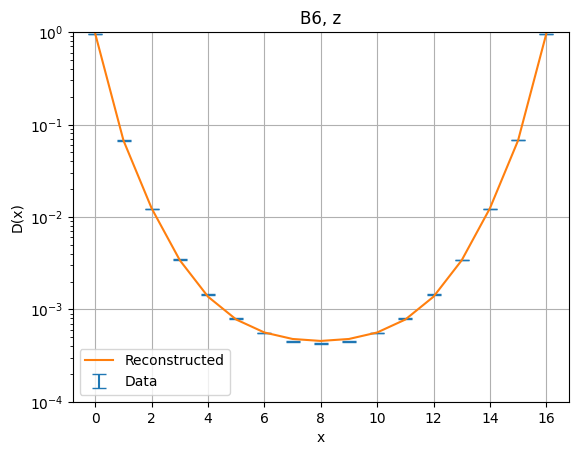

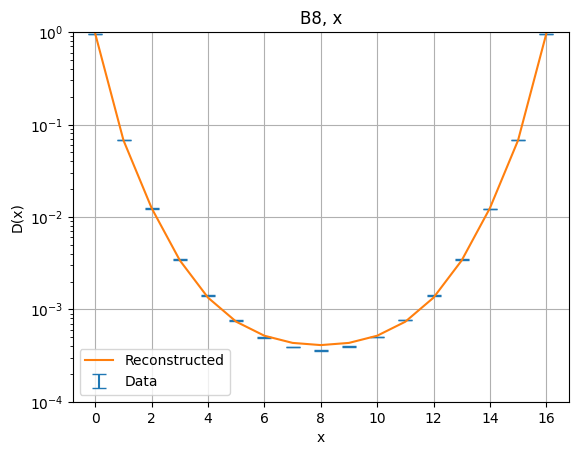

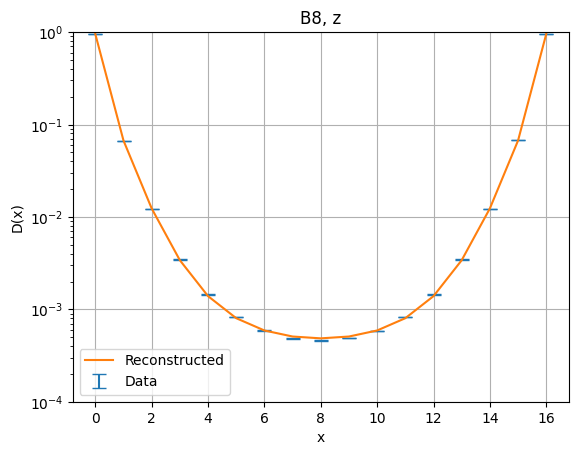

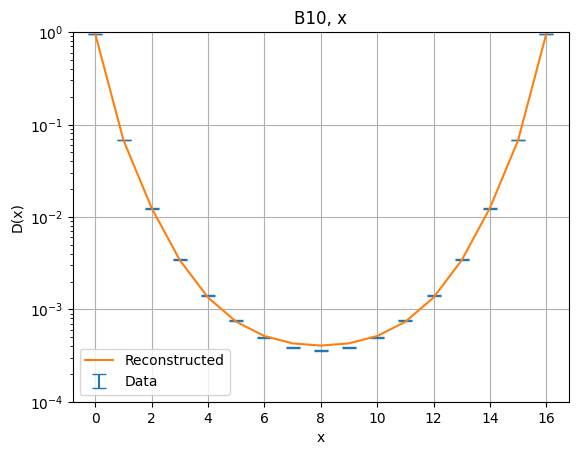

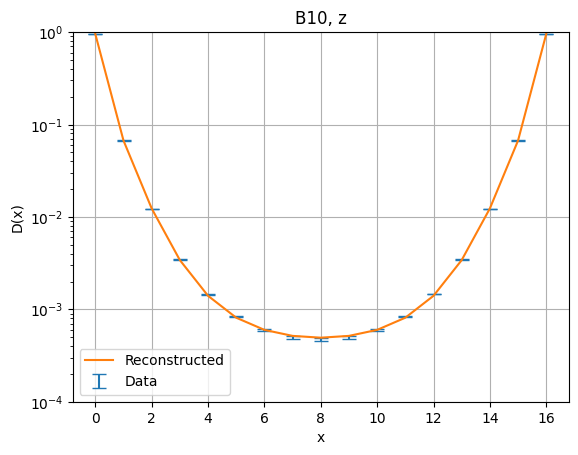

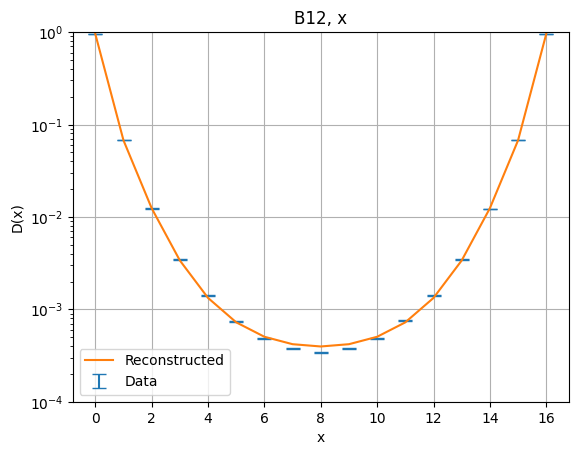

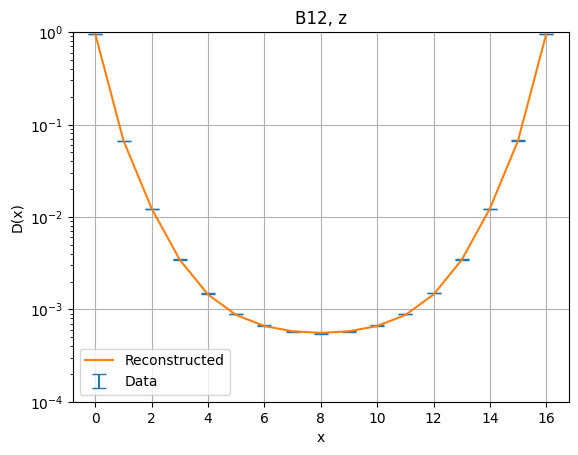

In [48]:
for (x,mean,error,jack,Label),(x_reconstructed,Dxi_reconstructed,Label) in zip(lattice_data,reconstructed_data):
    f=plt.figure()
    # plt.errorbar(x, mean, yerr=error,label='Data',fmt='',ls='',capsize=5)
    # plt.plot(x_reconstructed,Dxi_reconstructed,label='Reconstructed')
    plt.title(Label)
    plt.yscale('log')
    plt.xlabel('x')
    plt.ylabel('D(x)')
    plt.grid()
    plt.legend()
    plt.ylim(1e-4,1e0)

In [3]:
import correlator

epsilon=1e-10
omega = np.linspace(epsilon,20,500)
del_omega = omega[1]-omega[0]
klW_ker_Pos=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_FiniteT,x,omega,args=(1/Nt,))
allFilesErrorWeighting=[
["correlator_zeroT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_24_36_b5.845_B0_x.txt", "correlator_zeroT_finiteB/data_wilson_emconduc_24_36_b5.845_B0_x.txt", "B0, x"],
["correlator_zeroT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_24_36_b5.845_B0_x.txt", "correlator_zeroT_finiteB/data_wilson_emconduc_24_36_b5.845_B0_x.txt", "B0, z"],
["correlator_zeroT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_24_36_b5.845_B2_x.txt", "correlator_zeroT_finiteB/data_wilson_emconduc_24_36_b5.845_B2_x.txt", "B2, x"],
["correlator_zeroT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_24_36_b5.845_B2_z.txt", "correlator_zeroT_finiteB/data_wilson_emconduc_24_36_b5.845_B2_z.txt", "B2, z"],
["correlator_zeroT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_24_36_b5.845_B4_x.txt", "correlator_zeroT_finiteB/data_wilson_emconduc_24_36_b5.845_B4_x.txt", "B4, x"],
["correlator_zeroT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_24_36_b5.845_B4_z.txt", "correlator_zeroT_finiteB/data_wilson_emconduc_24_36_b5.845_B4_z.txt", "B4, z"],
["correlator_zeroT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_24_36_b5.845_B6_x.txt", "correlator_zeroT_finiteB/data_wilson_emconduc_24_36_b5.845_B6_x.txt", "B6, x"],
["correlator_zeroT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_24_36_b5.845_B6_z.txt", "correlator_zeroT_finiteB/data_wilson_emconduc_24_36_b5.845_B6_z.txt", "B6, z"],
["correlator_zeroT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_24_36_b5.845_B8_x.txt", "correlator_zeroT_finiteB/data_wilson_emconduc_24_36_b5.845_B8_x.txt", "B8, x"],
["correlator_zeroT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_24_36_b5.845_B8_z.txt", "correlator_zeroT_finiteB/data_wilson_emconduc_24_36_b5.845_B8_z.txt", "B8, z"],
["correlator_zeroT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_24_36_b5.845_B10_x.txt","correlator_zeroT_finiteB/data_wilson_emconduc_24_36_b5.845_B10_x.txt","B10, x"],
["correlator_zeroT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_24_36_b5.845_B10_z.txt","correlator_zeroT_finiteB/data_wilson_emconduc_24_36_b5.845_B10_z.txt","B10, z"],
["correlator_zeroT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_24_36_b5.845_B12_x.txt","correlator_zeroT_finiteB/data_wilson_emconduc_24_36_b5.845_B12_x.txt","B12, x"],
["correlator_zeroT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_24_36_b5.845_B12_z.txt","correlator_zeroT_finiteB/data_wilson_emconduc_24_36_b5.845_B12_z.txt","B12, z"],
]

lattice_data=[]
reconstructed_data=[]
for rhoFile,correlatorFile,Label in allFilesErrorWeighting:        
    lattice_correlator = np.loadtxt(correlatorFile)
    x = lattice_correlator[:,0]
    mean=lattice_correlator[:,1]
    error=lattice_correlator[:,2]
    Jackknife_samples = lattice_correlator[:,3:].T
    Nt=16
    zv=.829
    #add first point as last point to make it periodic
    x = np.append(x, len(x))
    mean = np.append(mean, mean[0])
    error = np.append(error, error[0])
    Jackknife_samples = np.append(Jackknife_samples, Jackknife_samples[:,0:1], axis=1)
    numpoints = len(x)
    lattice_data.append([x, mean, error, Jackknife_samples,Label])
    rhoOverOmega = np.loadtxt(rhoFile)
    rhoOverOmega = rhoOverOmega[:,1]
    Dxi_reconstructed = correlator.Di(klW_ker_Pos,rhoOverOmega,del_omega)
    reconstructed_data.append([x,Dxi_reconstructed,Label])


2025-01-22 15:26:31.282027: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-22 15:26:31.282582: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-22 15:26:31.284767: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-22 15:26:31.290330: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1737555991.300066   40987 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1737555991.30

/tmp/ipykernel_40987/345180481.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


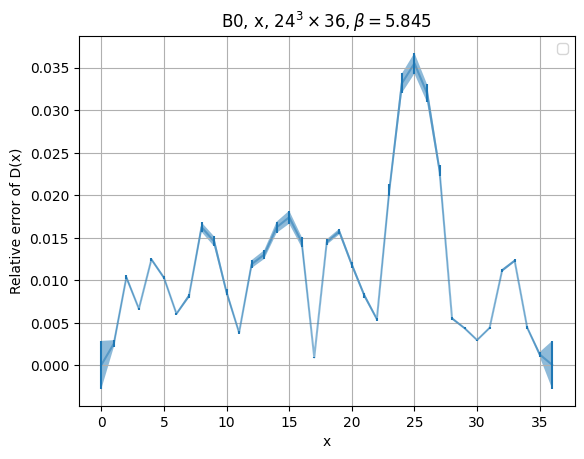

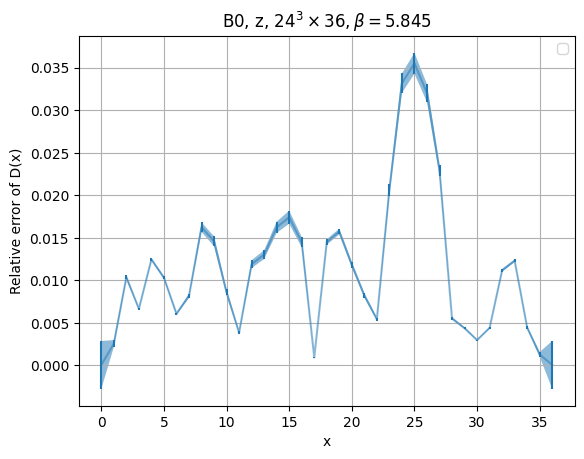

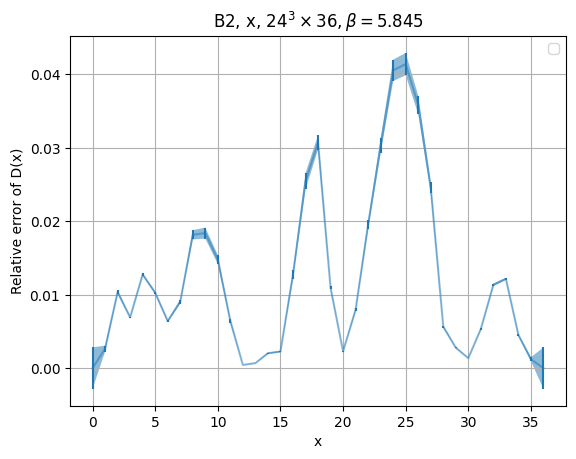

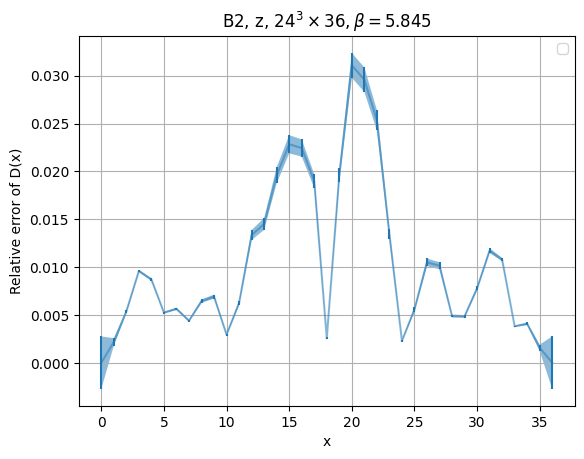

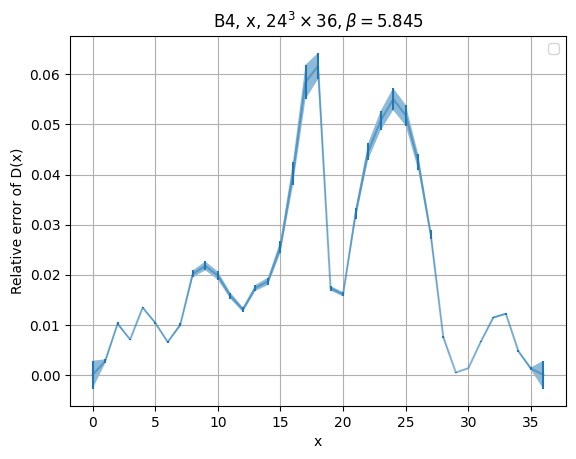

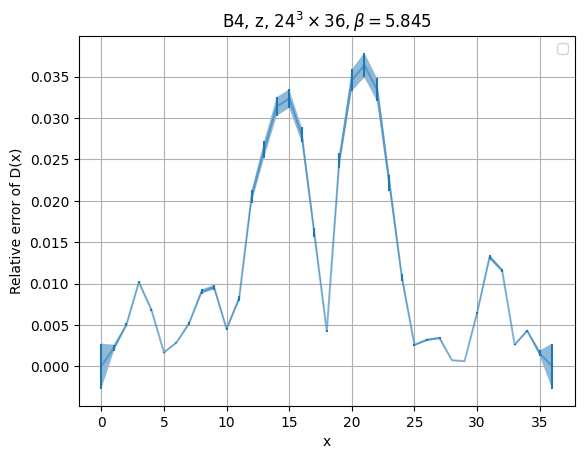

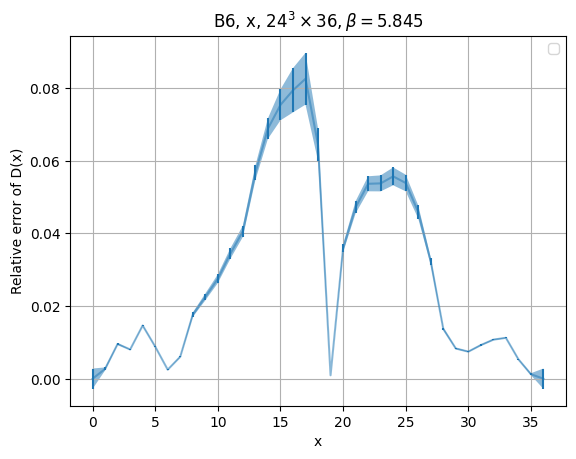

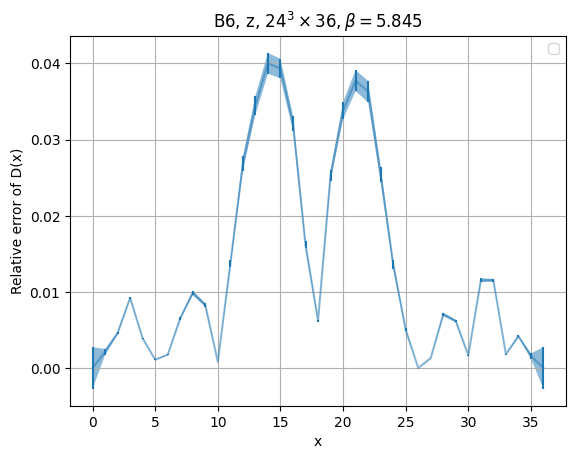

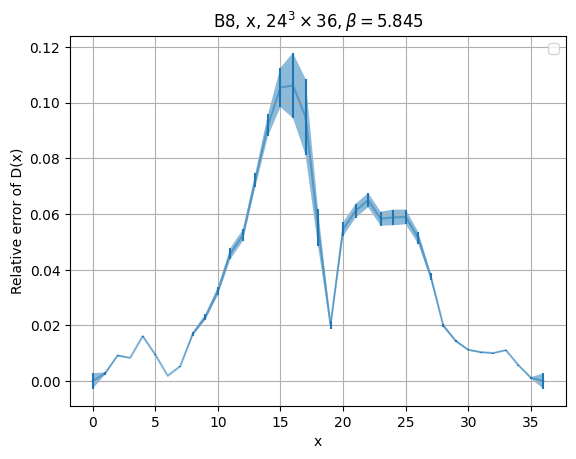

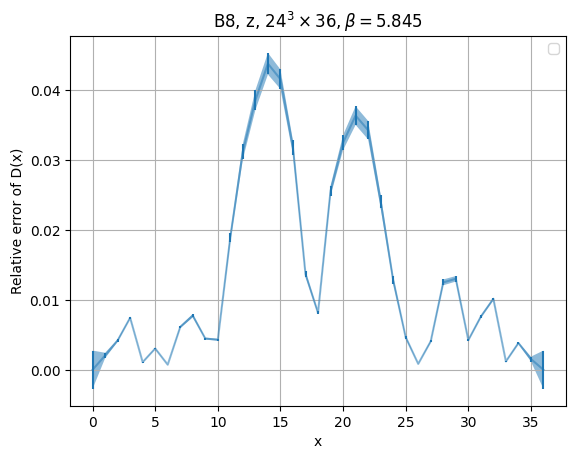

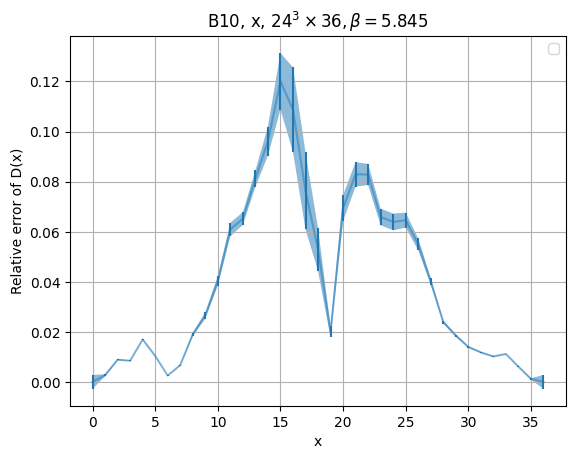

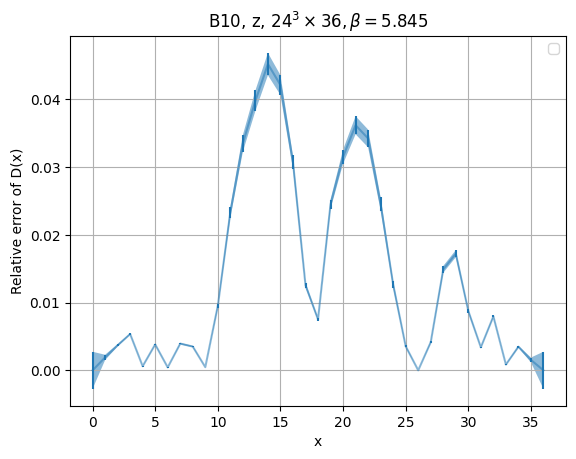

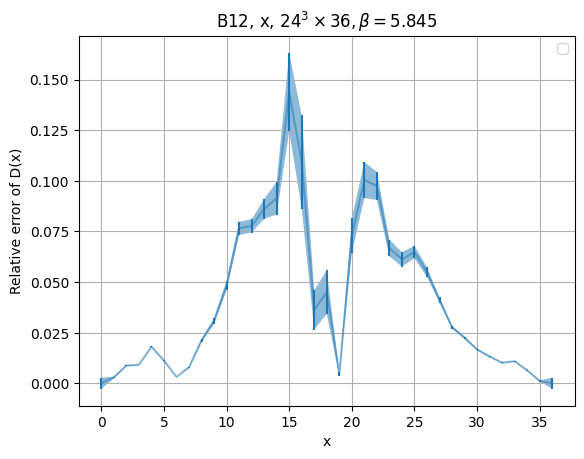

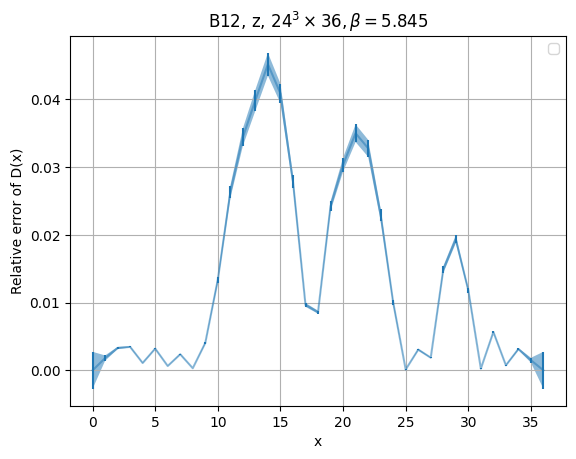

In [26]:
for (x,mean,error,jack,Label),(x_reconstructed,Dxi_reconstructed,Label) in zip(lattice_data,reconstructed_data):
    f=plt.figure()
    # plt.errorbar(x, mean, yerr=error,label='Data',fmt='',ls='',capsize=5)
    # plt.plot(x_reconstructed,Dxi_reconstructed,label='Reconstructed')
    relerr=np.abs(mean-Dxi_reconstructed)/mean
    errrelerr=np.sqrt((error/mean)**2+(error/relerr)**2)*relerr
    plt.errorbar(x,relerr,yerr=errrelerr,ls='')
    plt.plot(x,relerr,ls='-',alpha=0.5,color='C0')
    plt.fill_between(x,relerr-errrelerr,relerr+errrelerr,alpha=0.5)
    plt.title(Label+r", $24^3\times 36, \beta=5.845$")
    # plt.yscale('log')
    plt.xlabel('x')
    plt.ylabel('Relative error of D(x)')
    plt.grid()
    plt.legend()
    # plt.ylim(1e-4,1e0)

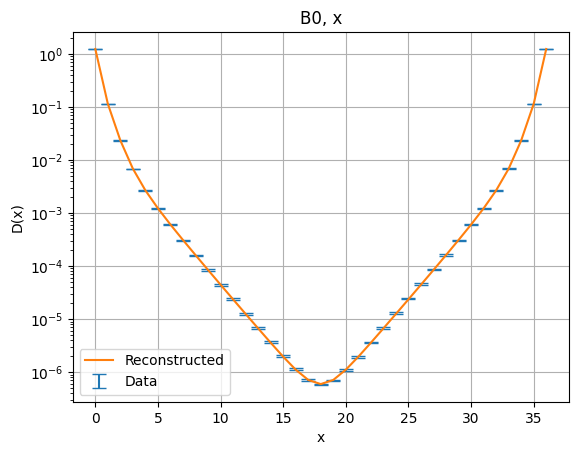

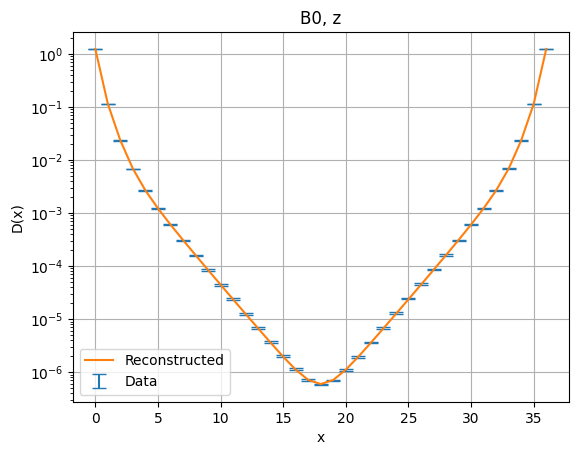

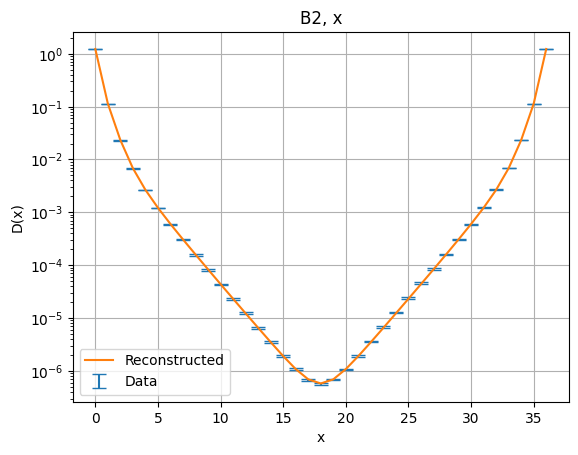

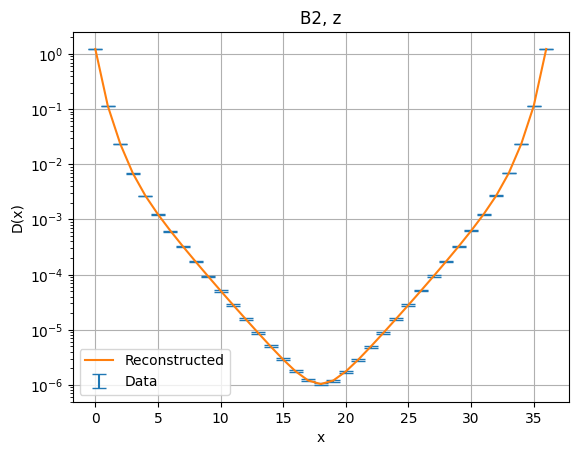

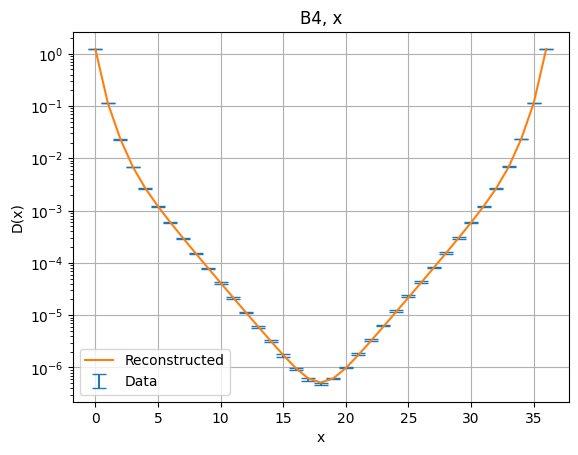

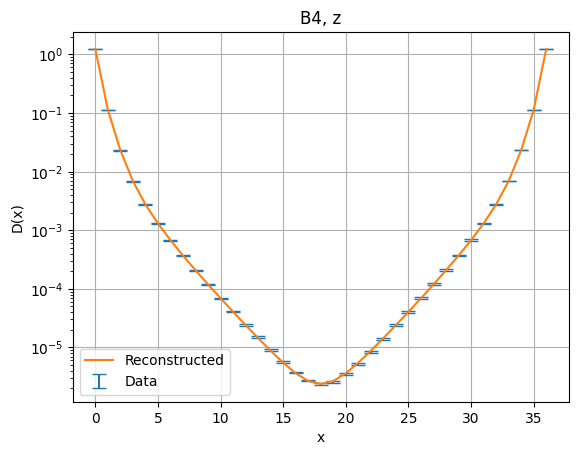

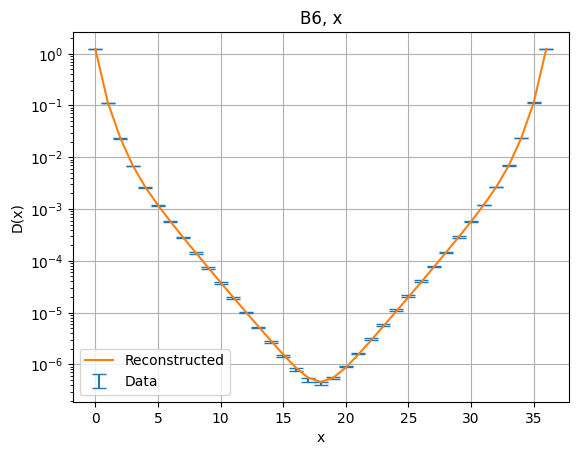

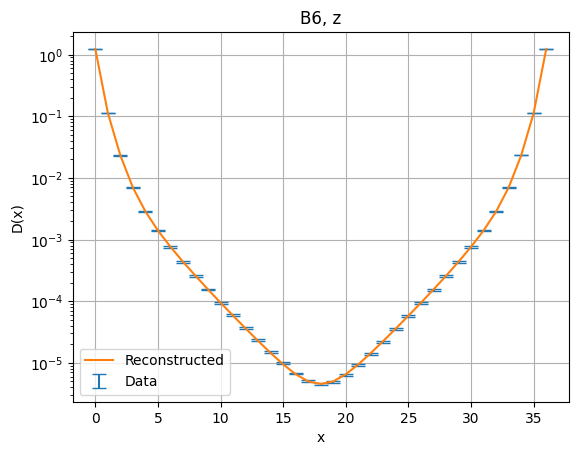

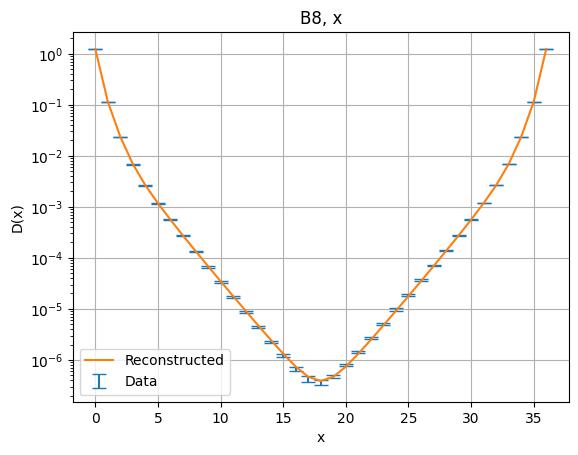

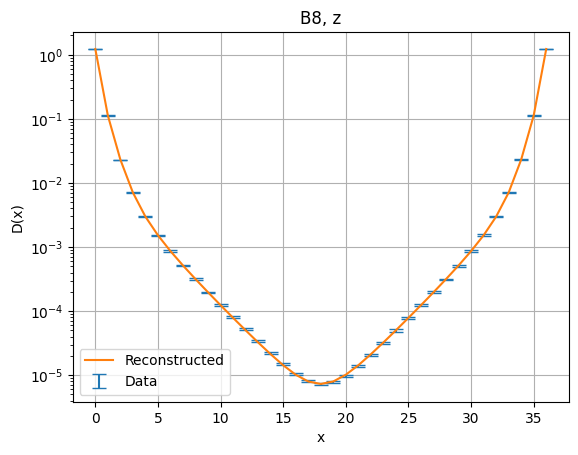

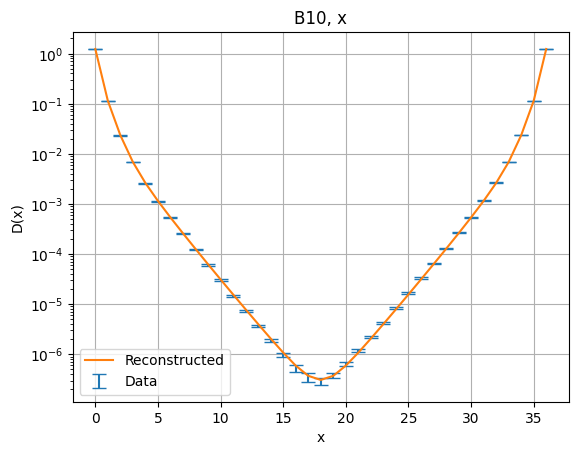

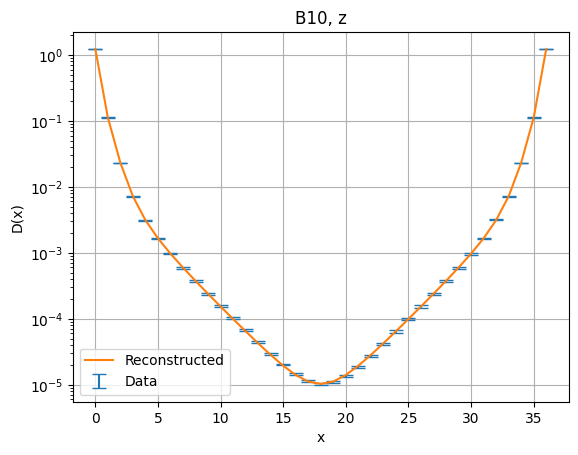

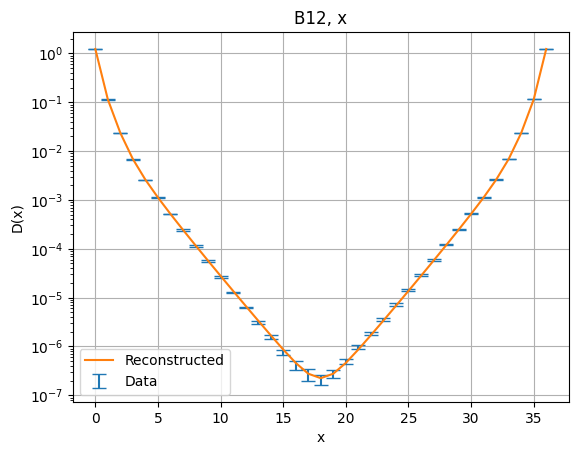

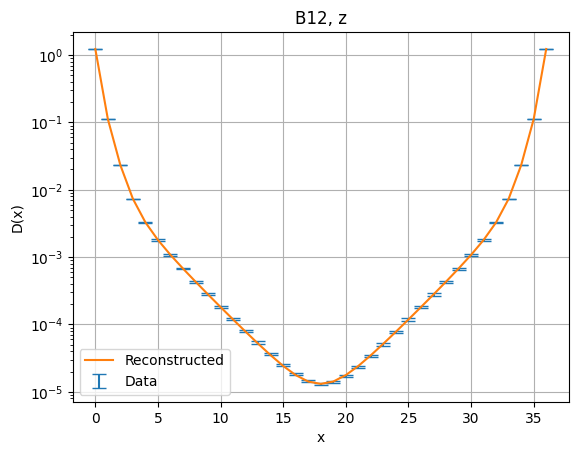

In [6]:
for (x,mean,error,jack,Label),(x_reconstructed,Dxi_reconstructed,Label) in zip(lattice_data,reconstructed_data):
    f=plt.figure()
    plt.errorbar(x, mean, yerr=error,label='Data',fmt='',ls='',capsize=5)
    plt.plot(x_reconstructed,Dxi_reconstructed,label='Reconstructed')
    plt.title(Label)
    plt.yscale('log')
    plt.xlabel('x')
    plt.ylabel('D(x)')
    plt.grid()
    plt.legend()
    # plt.ylim(1e-4,1e0)